# Dynamic Correlations with State-Space Smoothing

<a target="_blank" href="https://colab.research.google.com/github/ANDA-NI-2026/ANDA-Day2-State-Space-Analysis/blob/main/03_dynamic_correlations/03_exercises.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Setup

### Import Libraries

Import the modules required for this session. Run all cells in this section before starting the exercises.

**Note**: This notebook uses a local libary that sits in the `/ssll` folder. Before we can import from it we must call `sys.path.insert(0, 'ssll')` to add that folder to the path where Python can find it.

In [ ]:
# When running in Google Colabm, uncomment these lines to download the ssll library
#!wget -O ssll.zip "https://uni-bonn.sciebo.de/s/MnQ7swMFGpneoYB/download"
#!unzip -q ssll.zip

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Import modules from local library /ssll
import sys
sys.path.insert(0, 'ssll')
import ssll
import synthesis
import transforms
import energies

When working with custom libraries, it is a good practice to test that it is working as expected. The cell below runs the code with some example paramerters and uses `assert` to verify the output is as expected. The cell should print: `"Setup OK: shapes (5, 6) (5, 8) (5, 10, 3)"`

In [ ]:
N_test, O_test, T_test, R_test = 3, 2, 10, 20
transforms.initialise(N_test, O_test)
theta_test = synthesis.generate_thetas(N_test, O_test, T_test)
p_test = np.array([transforms.compute_p(theta_test[t]) for t in range(T_test)])
spikes_test = synthesis.generate_spikes(p_test, R_test)
assert spikes_test.shape == (T_test, R_test, N_test), f"Expected (10,20,3), got {spikes_test.shape}"
print(f"Setup OK: shapes {theta_test.shape} {p_test.shape} {spikes_test.shape}")

Setup OK: shapes (10, 6) (10, 8) (10, 20, 3)


### Utility Functions

The `utils` class below provides two plotting helpers used throughout the exercises. Run this cell once as part of Setup — you do not need to study the implementation.

In [ ]:
class utils:
    @staticmethod
    def plot_trajectory(theta_true, theta_est, ylabel, label='Smoothed estimate', ax=None):
        """Ground-truth vs a single estimated parameter trajectory."""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(theta_true, 'k--', label='Ground truth')
        ax.plot(theta_est, label=label)
        ax.set_xlabel('Time bin')
        ax.set_ylabel(ylabel)
        ax.legend()
        plt.tight_layout()
        return ax

    @staticmethod
    def plot_trajectory_with_band(theta_true, theta_est, std, ylabel):
        """Ground-truth vs estimated trajectory with a ±2σ credible band."""
        fig, ax = plt.subplots(figsize=(10, 3))
        t_ax = np.arange(len(theta_est))
        ax.plot(theta_true, 'k--', label='Ground truth')
        ax.plot(theta_est, label=r'Smoothed $\pm 2\sigma$')
        ax.fill_between(t_ax, theta_est - 2*std, theta_est + 2*std, alpha=0.3)
        ax.set_xlabel('Time bin')
        ax.set_ylabel(ylabel)
        ax.legend()
        plt.tight_layout()

## Simulating Time-Varying Neural Correlations

In many neural circuits, the statistical relationships between neurons change over time, i.e., activity is non-stationary. Neurons may display synchronization during a stimulus or internal brain state, and decouple at other times. To study such dynamic changes it is necessary to track how the pairwise interaction parameters $\theta$ evolve over time.

The function `synthesis.generate_thetas` draws a smooth trajectory of natural parameters $\theta_t$ from a Gaussian process (GP) prior, producing continuous curves for the biases and couplings. Each time step has its own $\theta$ vector, so the probability distribution $P(x|\theta_t)$ over spike patterns changes continuously. The parameter `sigma1` controls the smoothness of the bias trajectories, and `sigma2` controls the smoothness of the coupling trajectories. Both default to 50 time bins, meaning the parameters fluctuate on a timescale of roughly 50 bins. Smaller values produce faster, more jagged dynamics; larger values produce slower, smoother ones.

Generating spikes from a time-varying model produces a three-dimensional array of shape `(T, R, N)`: `T` time bins, each with `R` independent trials drawn from the pattern distribution at that time bin. The trial-averaged firing rate at each time bin, obtained by `spikes.mean(axis=1)`, reflects the instantaneous marginal probabilities and reveals how population activity changes across the recording.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`synthesis.generate_thetas(N, O, T)`** | Time-varying ground truth, shape `(T, D)` |
| **`synthesis.generate_thetas(N, O, T, sigma1=50, sigma2=50)`** | Set GP length scales for biases and couplings (default: 50 bins each) |
| **`synthesis.generate_thetas(N, O, T, mu2=...)`** | Prior mean for coupling parameters (default 0) |
| **`synthesis.generate_stationary_thetas(N, O, T)`** | Constant ground-truth parameters, shape `(T, D)` |
| **`theta[:, :N]`** | Bias parameters for each neuron |
| **`theta[:, N:]`** | Coupling parameters for each neuron pair |
| **`spikes.mean(axis=1)`** | Trial-averaged firing rate per neuron and time bin, shape `(T, N)` |

### Exercises

**Example:** Generate `N=3`, `O=2`, `T=200`, `R=100`. Plot biases and couplings represented by the natural parameters $\theta_t$ over time.

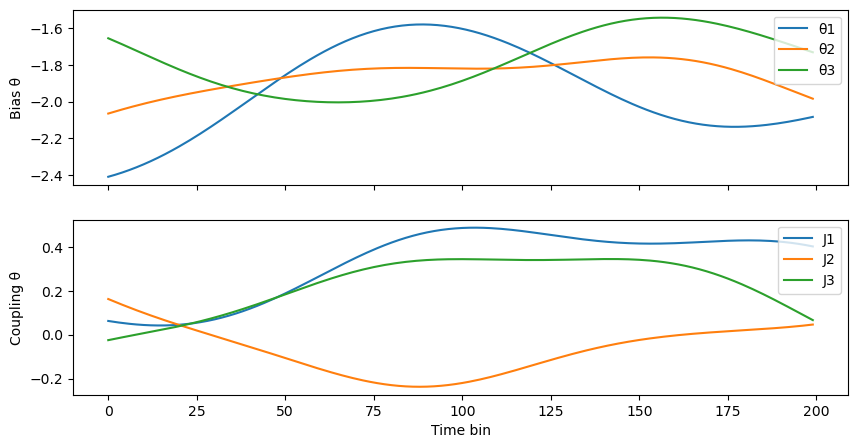

In [ ]:
N, O, T, R = 3, 2, 200, 100

transforms.initialise(N, O)
theta = synthesis.generate_thetas(N, O, T, sigma1=50, sigma2=50)  # default values
p = np.array([transforms.compute_p(theta[t]) for t in range(T)])
spikes = synthesis.generate_spikes(p, R)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for i in range(N):
    axes[0].plot(theta[:, i], label=f'θ{i+1}')
axes[0].set_ylabel('Bias θ')
axes[0].legend(loc='upper right')
for k in range(N * (N-1) // 2):
    axes[1].plot(theta[:, N + k], label=f'J{k+1}')
axes[1].set_ylabel('Coupling θ')
axes[1].set_xlabel('Time bin')
axes[1].legend(loc='upper right');

**Exercise:** Print `spikes.shape` of the example and verify it matches `(T, R, N)`.

**Exercise:** Plot the trial-averaged firing rates `spikes.mean(axis=1)` alongside the bias parameters `theta[:, :N]` (e.g., in a two-panel figure with shared x-axis). Does each neuron's rate track its bias parameter over time?

**Exercise:** Regenerate with `sigma1=150` (slow variation) and `sigma1=20` (fast variation). Plot both bias traces (first natural parameter $\theta$) for neuron 0 on the same axis.

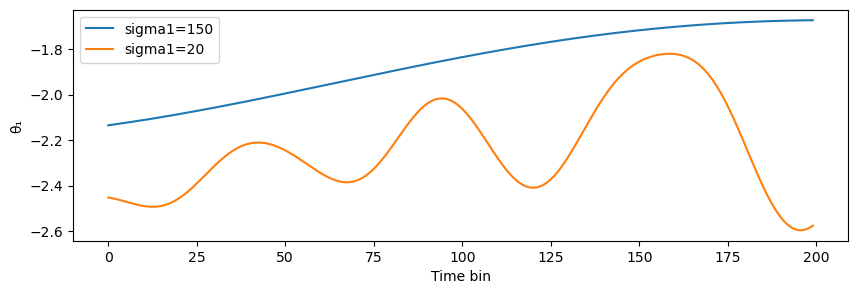

**Exercise:** Generate data with a stronger mean coupling (`mu2=1.5`); store the result as `theta_strong_coupling`. Plot the coupling traces and compare to the default `mu2=0` case.

**Exercise:** Generate stationary thetas using `synthesis.generate_stationary_thetas(N, O, T)`. Verify that all parameters are constant over time by printing `theta_stat[0]` (first time bin) and `theta_stat[-1]` (last time bin) — they should be identical.

## Running the State-Space Analysis

The state-space model treats the natural parameters $\theta_t$ as a hidden state that evolves according to $\theta_t = \theta_{t-1} + \varepsilon_t$, where $\varepsilon_t \sim \mathcal{N}(0, Q)$ is a small random perturbation. This random-walk prior favors smooth trajectories while allowing the parameters to change over time. At each time step, the R observed spike patterns provide a noisy window into the current $\theta_t$.

The SSLL algorithm combines the prior with the data using a Kalman filter (forward pass) and a Rauch-Tung-Striebel smoother (backward pass) to produce the posterior distribution of $\theta_t$ given all $T \times R$ observations. The result `emd.theta_s` is the smoothed posterior mean and `emd.sigma_s` is the corresponding posterior covariance. The state noise covariance Q is learned from the data during the M-step.

The learned Q, stored in `emd.Q`, reflects how much the algorithm believes the parameters change from one time bin to the next. A larger diagonal of Q implies the model has inferred faster dynamics.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`ssll.run(spikes, order)`** | Run filter + smoother + M-step; returns EMData |
| **`emd.theta_s`** | Smoothed posterior mean, shape `(T, D)` |
| **`emd.sigma_s`** | Smoothed posterior covariances, shape `(T, D, D)` |
| **`emd.Q`** | Learned state noise covariance, shape `(D, D)` |
| **`emd.mll_list`** | Log marginal likelihood at each EM iteration |
| **`emd.mll`** | Final log marginal likelihood |
| **`utils.plot_trajectory(theta_true, theta_est, ylabel)`** | Two-line plot: ground truth (dashed) vs estimate |

### Exercises

**Example:** Fit the model and compare the smoothed bias of neuron 0 to the ground truth.

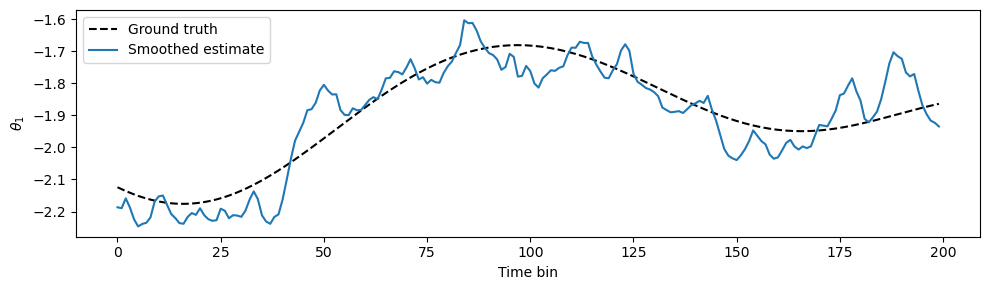

In [ ]:
N, O, T, R = 3, 2, 200, 100

transforms.initialise(N, O)
theta = synthesis.generate_thetas(N, O, T)
p = np.array([transforms.compute_p(theta[t]) for t in range(T)])
spikes = synthesis.generate_spikes(p, R)
emd = ssll.run(spikes, order=O, EM_Info=False)

utils.plot_trajectory(theta[:, 0], emd.theta_s[:, 0], r'$\theta_1$');

**Exercise:** Print `emd.theta_s.shape`. Print the diagonal of `emd.Q` as a relative indicator of how fast parameters are evolving.

**Exercise:** Compute the mean squared error of the smoothed estimate, separately for biases (first `N` columns of `emd.theta_s`) and couplings (remaining columns).

**Exercise:** Plot the smoothed estimate of the first coupling `emd.theta_s[:, N]` against the ground truth `theta[:, N]`.

**Exercise:** Plot `emd.mll_list` and print the number of EM iterations.

**Exercise:** Increase `R` to `R=300` and refit. How does the MSE change compared to `R=100`?

## Filtered vs Smoothed Estimates and Uncertainty

The forward filter processes the data from left to right in time, estimating $\theta_t$ using only the observations up to time $t$. This is a causal estimate that could be used in real-time processing. The backward smoother then refines these estimates by propagating information from later time bins back to earlier ones, producing the non-causal smoothed estimate `emd.theta_s`. Because the smoother has access to future data, it is typically more accurate than the filtered estimate `emd.theta_f`, and the posterior covariance `emd.sigma_s` is correspondingly smaller.

The posterior standard deviation at each time bin quantifies the algorithm's confidence in its estimate. At the edges of the recording, the smoother has less data to work with (before the start or after the end of the smoothing window), so posterior uncertainty is typically higher there. Comparing `emd.sigma_s` and `emd.sigma_f` reveals exactly how much the future observations reduce uncertainty about the current state.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`emd.theta_f`** | Filtered estimate (causal, forward-only), shape `(T, D)` |
| **`emd.theta_s`** | Smoothed estimate (non-causal), shape `(T, D)` |
| **`emd.sigma_f`** | Filtered covariances, shape `(T, D, D)` |
| **`emd.sigma_s`** | Smoothed covariances, shape `(T, D, D)` |
| **`np.sqrt(emd.sigma_s[:, i, i])`** | Posterior standard deviation for parameter i over time |
| **`utils.plot_trajectory_with_band(theta_true, theta_est, std, ylabel)`** | Plot estimate with a shaded ±2σ credible band |

### Exercises

*Run the cell below only if you are starting here without having completed Section 2; it regenerates `N`, `O`, `T`, `R`, `theta`, `p`, `spikes`, and the fitted `emd`.*

In [ ]:
# Realign: run this cell if you are starting Section 3 without having run Section 2
# Sets up: N, O, T, R, theta, p, spikes, emd
N, O, T, R = 3, 2, 200, 100

transforms.initialise(N, O)
theta = synthesis.generate_thetas(N, O, T)
p = np.array([transforms.compute_p(theta[t]) for t in range(T)])
spikes = synthesis.generate_spikes(p, R)
emd = ssll.run(spikes, order=O, EM_Info=False)

print(f'Realign OK — N={N}, T={T}, R={R}, emd fitted')

Realign OK — N=3, T=200, R=100, emd fitted


**Example:** Plot `theta_f[:, 0]` and `theta_s[:, 0]` together with the ground truth $\theta$ to compare filtered and smoothed estimates.

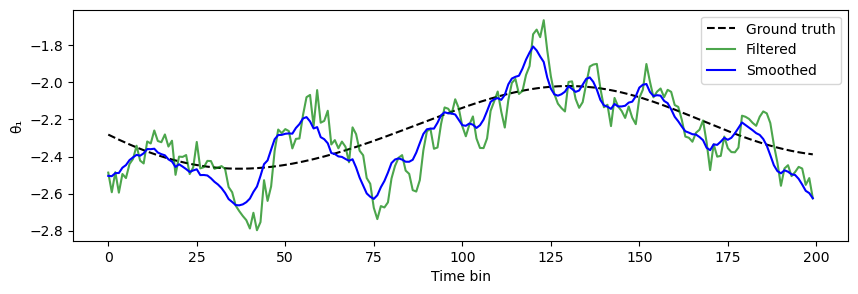

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(theta[:, 0], 'k--', label='Ground truth')
ax.plot(emd.theta_f[:, 0], 'g', alpha=0.7, label='Filtered')
ax.plot(emd.theta_s[:, 0], 'b', label='Smoothed')
ax.set_xlabel('Time bin')
ax.set_ylabel('\u03b8\u2081')
ax.legend();

**Exercise:** Compute the posterior standard deviation `np.sqrt(emd.sigma_s[:, 0, 0])`, store it as `std_s`, and add a shaded $\pm 2\sigma$ band around the smoothed estimate.

**Exercise:** Using `std_s` from the previous exercise, compute the fraction of time bins where the true $\theta_1(t)$ falls within the $\pm 2\sigma$ credible interval.

**Exercise:** Compute `std_f = np.sqrt(emd.sigma_f[:, 0, 0])`. Compare the mean posterior standard deviation of the filtered vs smoothed estimate.

**Exercise:** At which time bin is the smoothed posterior standard deviation largest? Why might the edges of the recording have higher uncertainty?



**Exercise:** Halve the number of trials (`R=50`). Regenerate the spikes and refit; store the new posterior std as `std_s50`. Compare `std_s50.mean()` to `std_s.mean()` from above. How do the posterior standard deviations change?

## Controlling the State Dynamics (Optional)

The parameter `state_cov` sets the initial state noise covariance $Q$ and controls what the EM algorithm optimizes. A small value forces the estimated parameters to vary slowly and smoothly over time. A larger value allows the model to track rapid changes but results in noisier estimates. You can set different noise levels for biases and couplings by passing a two-element list: `state_cov=[lambda_1, lambda_2]` assigns `lambda_1` to the $N$ bias parameters and `lambda_2` to the $N(N-1)/2$ coupling parameters. Setting `lambda_2=0` forces the couplings to remain constant while biases are allowed to vary.

This flexibility is useful when you have prior knowledge about the dynamics of different parameter types. For example, firing rates often drift on a slow timescale driven by neuromodulation, while pairwise correlations may be more stable during a single session. Constraining the coupling dynamics can improve inference quality when the available data is limited.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`state_cov=0.001`** | Small noise prior: smoother, less responsive |
| **`state_cov=0.1`** | Larger noise prior: more responsive, noisier |
| **`state_cov=0`** | Fully stationary model (no dynamics) |
| **`state_cov=[0.01, 0.0]`** | Biases dynamic, couplings held constant |
| **`emd.mll`** | Final log marginal likelihood |

### Exercises

*Run the cell below only if you are starting here without having completed Sections 1 and 2; it regenerates `N`, `O`, `T`, `R`, `theta`, `p`, `spikes`, and the fitted `emd`.*

In [ ]:
# Realign: run this cell if you are starting Section 4 without having run Sections 1 and 2
# Sets up: N, O, T, R, theta, p, spikes, emd
N, O, T, R = 3, 2, 200, 100

transforms.initialise(N, O)
theta = synthesis.generate_thetas(N, O, T)
p = np.array([transforms.compute_p(theta[t]) for t in range(T)])
spikes = synthesis.generate_spikes(p, R)
emd = ssll.run(spikes, order=O, EM_Info=False)

print(f'Realign OK — N={N}, T={T}, R={R}, emd fitted')

Realign OK — N=3, T=200, R=100, emd fitted


**Example:** Compare smoothed bias estimates under two different `state_cov` values (e.g., 0.001 and 0.1).

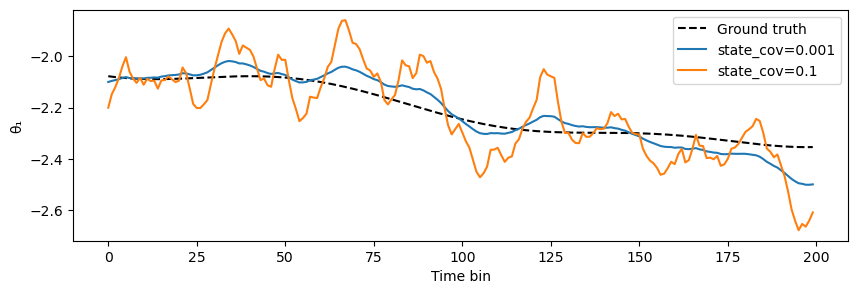

In [ ]:
emd_slow = ssll.run(spikes, order=O, state_cov=0.001, EM_Info=False)
emd_fast = ssll.run(spikes, order=O, state_cov=0.1, EM_Info=False)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(theta[:, 0], 'k--', label='Ground truth')
ax.plot(emd_slow.theta_s[:, 0], label='state_cov=0.001')
ax.plot(emd_fast.theta_s[:, 0], label='state_cov=0.1')
ax.set_xlabel('Time bin')
ax.set_ylabel('\u03b8\u2081')
ax.legend();

**Exercise:** Run SSLL with `state_cov=[0.01, 0.0]` (dynamic biases, static couplings); store the result as `emd_mixed`. Plot `emd_mixed.theta_s[:, N]` over time against the ground truth `theta[:,N]` of the first coupling using the `plot_trajectory utility` function. Is the coupling approximately constant?

**Exercise:** Run with `state_cov=0` (fully stationary model); store the result as `emd_stat`. Plot the bias estimate for neuron 0 `emd_stat.theta_s[:, 0]` over time and verify it is flat.

**Exercise:** Compare `emd.mll` with `emd_stat.mll`. Which model achieves a higher log marginal likelihood on the time-varying data?

**Exercise:** Generate truly stationary data with `synthesis.generate_stationary_thetas`. Fit both the dynamic and stationary models. Compare their `mll` values. Which model wins when the data is truly stationary?

## Thermodynamic Analysis of Dynamic Populations (Optional)

The thermodynamic analysis from Session 1 can be applied for each time-bin to track how the role of pairwise interactions changes over the recording. When coupling parameters are large at time $t$, the entropy ratio $S_\text{ratio}(t)$ is high: a large fraction of the population variability is explained by pairwise interactions at that moment. When couplings are near zero, $S_\text{ratio}(t)$ is near zero and the population behaves essentially independently.

The KL divergence $D_\text{KL}(t)$ measures how much information would be lost by switching from the pairwise model to the independent model at time $t$. Together, the time courses of $S_\text{ratio}$ and $D_\text{KL}$ indicate when in the recording population interactions are most important, potentially revealing dynamics related to stimulus processing, behavioral state, or network phenomena.

Both $S_\text{ratio}$ and $D_\text{KL}$ are computed from the smoothed posterior mean `emd.theta_s`, so they inherit the uncertainty of the state estimation. A time bin with high posterior variance will produce less reliable thermodynamic estimates. When interpreting these quantities, it is useful to overlay the posterior uncertainty to distinguish genuine dynamics from estimation noise.

*Note: this section focuses on dynamic entropy estimation ($S_\text{ratio}(t)$) and KL divergence as measures of pairwise interaction strength. Heat capacity, an equally informative thermodynamic quantity, would require additional computation and is not covered here.*

### Code Reference

| Code | Description |
| :-- | :-- |
| **`energies.get_energies(emd)`** | Compute $S_1$, $S_2$, $S_\text{ratio}$, $D_\text{KL}$ for all $T$ time bins |
| **`emd.S2`** | Entropy of pairwise model, shape `(T,)` |
| **`emd.S_ratio`** | Time-varying entropy ratio, shape `(T,)` |
| **`emd.dkl`** | Time-varying KL divergence, shape `(T,)` |

### Exercises

*Run the cell below only if you are starting here without having completed Sections 1 and 2; it regenerates `N`, `O`, `T`, `R`, `theta`, `p`, `spikes`, and the fitted `emd`.*

In [ ]:
# Realign: run this cell if you are starting Section 5 without having run Sections 1 and 2
# Sets up: N, O, T, R, theta, p, spikes, emd (with thermodynamic quantities pre-computed)
N, O, T, R = 3, 2, 200, 100

transforms.initialise(N, O)
theta = synthesis.generate_thetas(N, O, T)
p = np.array([transforms.compute_p(theta[t]) for t in range(T)])
spikes = synthesis.generate_spikes(p, R)
emd = ssll.run(spikes, order=O, EM_Info=False)
energies.get_energies(emd)

print(f'Realign OK — N={N}, T={T}, R={R}, emd fitted and thermodynamic quantities computed')

Realign OK — N=3, T=200, R=100, emd fitted and thermodynamic quantities computed


**Example:** Compute thermodynamic quantities and plot the entropy ratio over time.

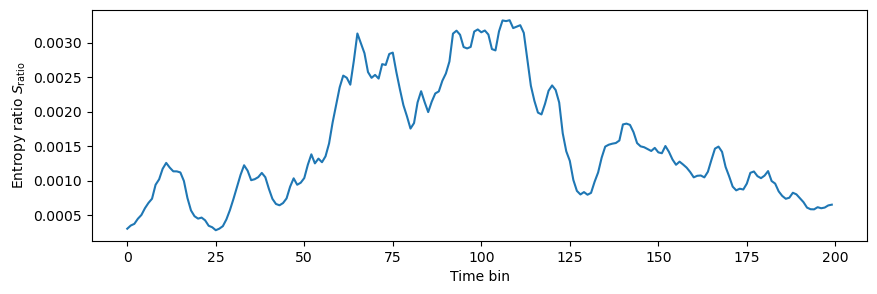

In [ ]:
energies.get_energies(emd)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(emd.S_ratio)
ax.set_xlabel('Time bin')
ax.set_ylabel(r'Entropy ratio $S_\mathrm{ratio}$')

**Exercise:** Plot `emd.S1` and `emd.S2` on the same axes. When is the gap between them largest?

**Exercise:** Overlay the first coupling parameter `emd.theta_s[:, N]` and `emd.S_ratio` on a dual-axis plot. Do strong couplings correspond to high entropy ratios?

**Exercise:** Plot `emd.dkl` over time. Print the time bin with maximum KL divergence.

**Exercise:** Fit an order=1 model to the same data and call energies.get_energies; store the result as `emd_ind`. Verify that the entropy ratio is approximately zero for all time bins.

**Exercise:** Generate a population with strong mean coupling (`mu2=1.5`). Run `ssll.run` and `energies.get_energies`. Compare the mean `emd.S_ratio` to the default coupling case and confirm your expectation.